# 04 — Model Training
Bounteous Motors AI — Vehicle Price Prediction

Trains and compares four candidate regression models — **Decision Tree**, **Random Forest**,
**Gradient Boosting**, and **XGBoost** — on top of a **Linear Regression** baseline, all sharing
the same cleaning → feature engineering → preprocessing pipeline built in the previous notebooks.

Each tuned model is selected with `RandomizedSearchCV` (cross-validated on the training set only),
then scored on a held-out test set for a fair comparison.

> **Note on search budget:** this notebook runs with a reduced hyperparameter search
> (`cv=3`, `n_iter=5`) so it finishes in a reasonable time for a live walkthrough. The full
> production grid (`cv=5`, `n_iter=15`, as configured in `config.py` / `tuning.py`) is what was
> used to produce the deployed `models/pipeline.pkl` and the progress report.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV

from config import TARGET_COLUMN, TEST_SIZE, RANDOM_STATE, FIGURES_DIR
from data_loader import load_dataset
from cleaning import clean_dataset
from feature_engineering import engineer_features
from preprocessing import create_preprocessor
from tuning import get_models, PARAMETERS
from evaluation import evaluate_model

pd.set_option("display.max_columns", None)

## Load, clean, and engineer features
Same pipeline as notebooks 02 and 03, reused directly from the project modules.

In [2]:
df = load_dataset()
df = clean_dataset(df)
df = engineer_features(df)
df.shape

Dataset loaded successfully: 7,253 rows × 14 columns
Starting dataset cleaning...
✓ Removed 0 duplicate rows.
✓ Dropped columns: ['S.No.', 'New_Price']
✓ Removed 1234 rows with missing Price.
✓ Cleaned Mileage.
✓ Cleaned Engine.
✓ Cleaned Power.
✓ Converted Price from USD to KES.
✓ Corrected 1 row(s) with 0 Seats (set to NaN for imputation).
✓ Filled missing values in 'Mileage' using median.
✓ Filled missing values in 'Engine' using median.
✓ Filled missing values in 'Power' using median.
✓ Filled missing values in 'Seats' using median.
✓ Standardized categorical columns.
✓ Dataset validation passed.
✓ Clean dataset saved to:
/home/claude/work/project/dataset/cleaned_used_cars_data.csv
Dataset cleaning complete.
Starting feature engineering...


✓ Brand extracted.
✓ Model extracted.
✓ Car_Age created.
✓ Luxury_Brand created.
✓ Kilometers_Per_Year created.
✓ Power_Per_CC created.
✓ Name column dropped.
Feature engineering complete.


(6019, 17)

## Train / test split

In [3]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]:,} rows   Test: {X_test.shape[0]:,} rows")

Train: 4,815 rows   Test: 1,204 rows


## Preprocessing pipeline
Median imputation + scaling for numeric features, most-frequent imputation + one-hot encoding for categorical features (`preprocessing.py`).

In [4]:
preprocessor = create_preprocessor()

✓ Preprocessing pipeline created.


## Train, tune, and evaluate each model
For each candidate model:
1. Wrap it with the shared `preprocessor` in a `Pipeline`.
2. Tune it with `RandomizedSearchCV` (skipped for Linear Regression, which has no hyperparameters to search).
3. Fit the tuned pipeline on the training set.
4. Evaluate on the held-out test set (MAE, RMSE, R², Train R²) and save diagnostic plots.

This mirrors exactly what `train.py` does end-to-end; here we do it model-by-model so each result
is visible as it happens.


Training Linear Regression...


No tuning required (Linear Regression baseline).
MODEL EVALUATION
MAE         : 451.8861
RMSE        : 1107.3984
R²          : 0.4103
Train R²    : 0.9705


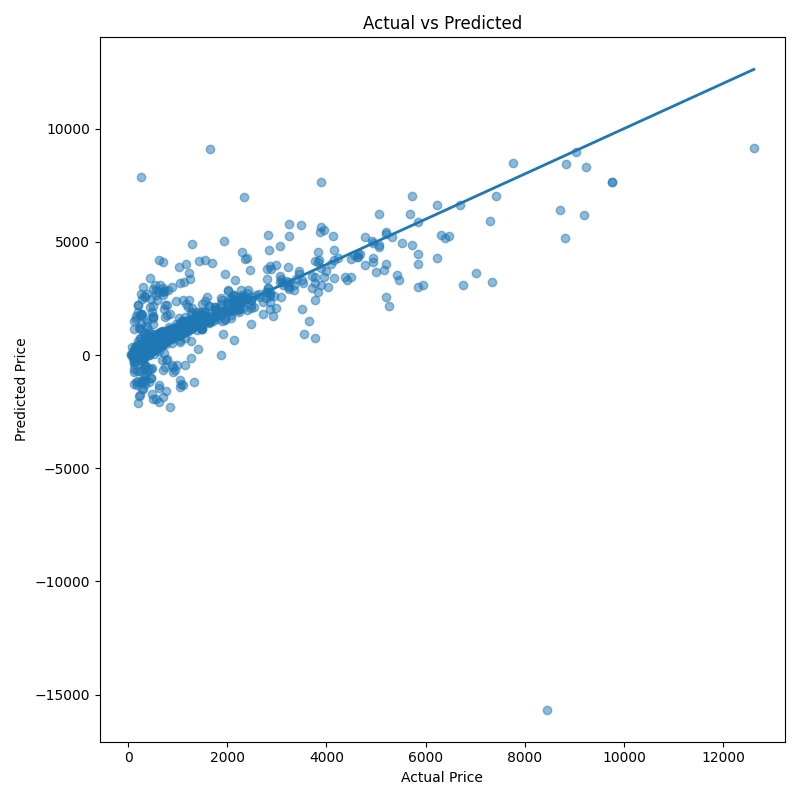


Training Decision Tree...


Best CV R² : 0.8035
MODEL EVALUATION
MAE         : 263.0187
RMSE        : 613.0556
R²          : 0.8193
Train R²    : 0.9444


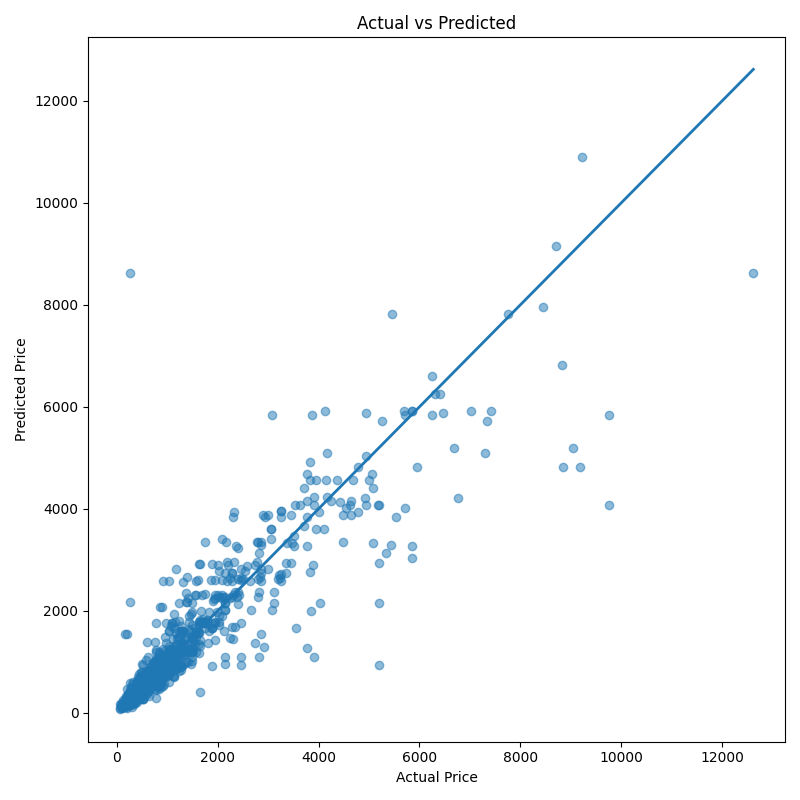


Training Random Forest...


Best CV R² : 0.8780


MODEL EVALUATION
MAE         : 203.6900
RMSE        : 499.9456
R²          : 0.8798
Train R²    : 0.9731


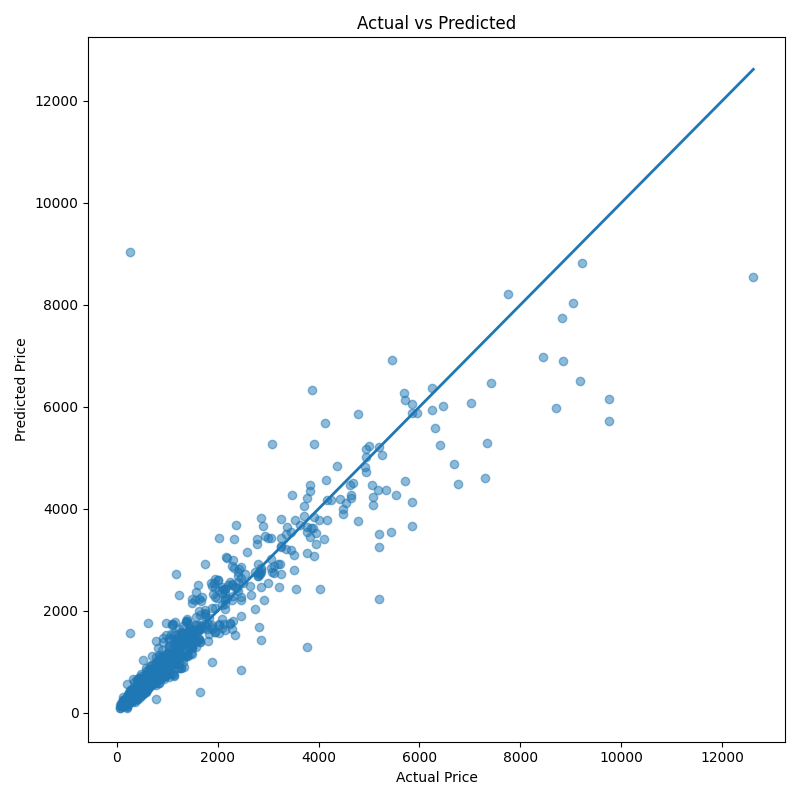


Training Gradient Boosting...


Best CV R² : 0.8805
MODEL EVALUATION
MAE         : 208.5848
RMSE        : 477.5917
R²          : 0.8903
Train R²    : 0.9773


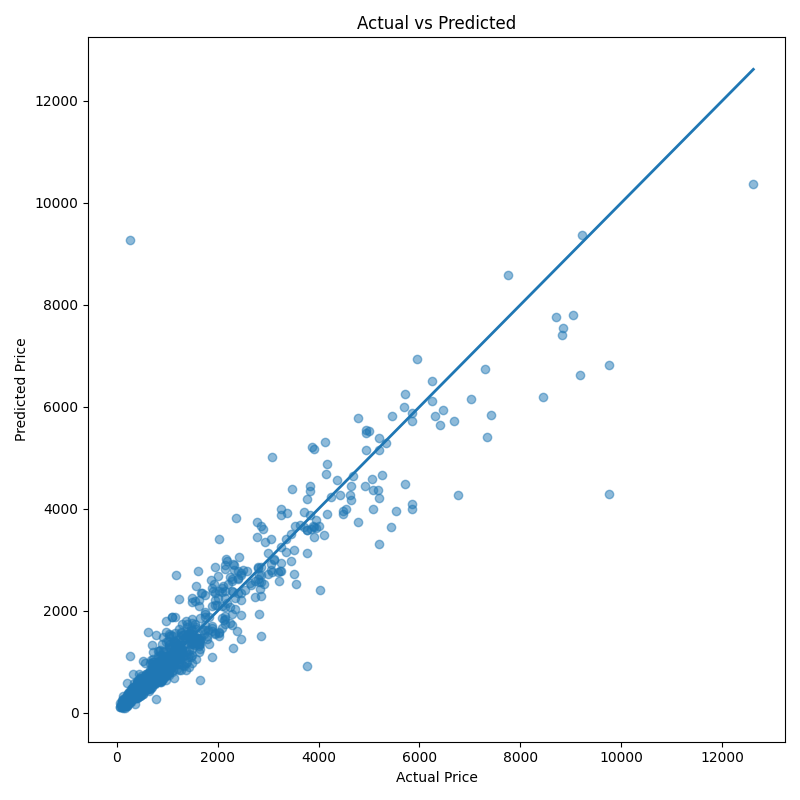


Training XGBoost...


Best CV R² : 0.8893
MODEL EVALUATION
MAE         : 220.8454
RMSE        : 486.9234
R²          : 0.8860
Train R²    : 0.9575


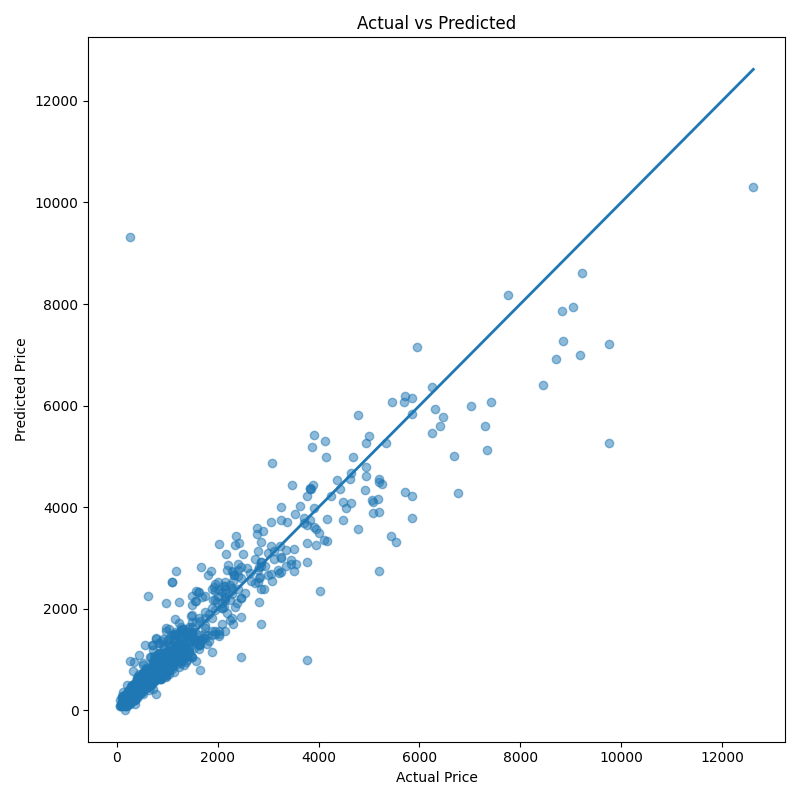

In [5]:
DEMO_CV = 3
DEMO_N_ITER = 5

results = {}
fitted_pipelines = {}

for name, model in get_models().items():

    print("\n" + "=" * 70)
    print(f"Training {name}...")
    print("=" * 70)

    start = time.time()

    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

    if name in PARAMETERS:
        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=PARAMETERS[name],
            cv=DEMO_CV,
            n_iter=DEMO_N_ITER,
            scoring="r2",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=0,
        )
        search.fit(X_train, y_train)
        print(f"Best CV R² : {search.best_score_:.4f}")
        best_pipeline = search.best_estimator_
        cv_score = search.best_score_
    else:
        pipeline.fit(X_train, y_train)
        print("No tuning required (Linear Regression baseline).")
        best_pipeline = pipeline
        cv_score = np.nan

    metrics = evaluate_model(best_pipeline, X_test, y_test, X_train, y_train)
    metrics["CV R2"] = cv_score
    metrics["Train Time (s)"] = round(time.time() - start, 1)

    results[name] = metrics
    fitted_pipelines[name] = best_pipeline

    display(Image(filename=str(FIGURES_DIR / "actual_vs_predicted.png")))

## Model comparison

In [6]:
results_df = pd.DataFrame(results).T
results_df = results_df[["CV R2", "R²", "Train R²", "MAE", "RMSE", "Train Time (s)"]]
results_df = results_df.rename(columns={"R²": "Test R2", "Train R²": "Train R2"})
results_df.sort_values("Test R2", ascending=False)

,CV R2,Test R2,Train R2,MAE,RMSE,Train Time (s)
Gradient Boosting,0.880460,0.890324,0.977288,208.584798,477.591710,46.5
XGBoost,0.889291,0.885996,0.957501,220.845417,486.923390,16.8
Random Forest,0.878008,0.879817,0.973073,203.689973,499.945573,371.4
Decision Tree,0.803494,0.819283,0.944403,263.018733,613.055645,5.7
Linear Regression,NaN,0.410334,0.970456,451.886116,1107.398367,0.7


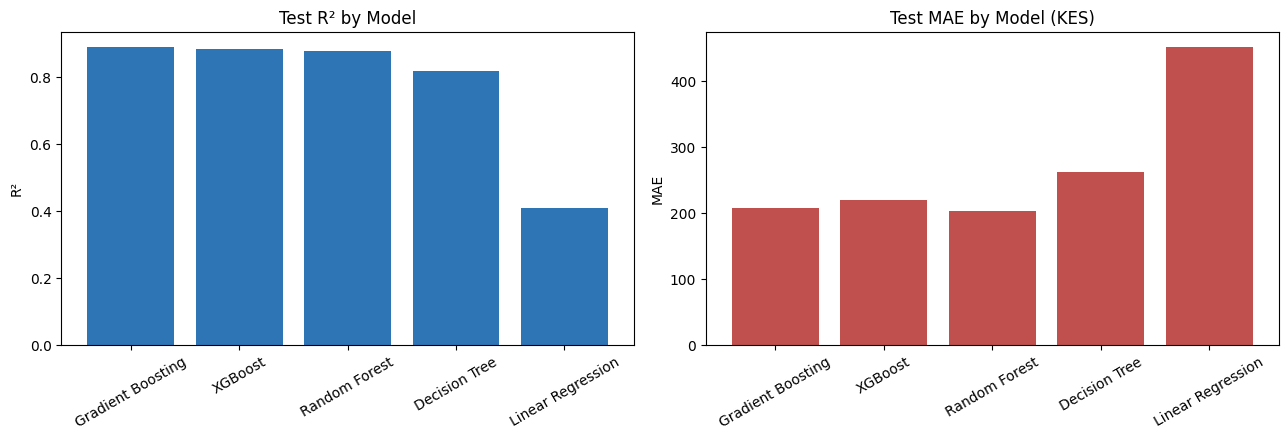

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

order = results_df.sort_values("Test R2", ascending=False).index

axes[0].bar(order, results_df.loc[order, "Test R2"], color="#2E75B6")
axes[0].set_title("Test R² by Model")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(order, results_df.loc[order, "MAE"], color="#C0504D")
axes[1].set_title("Test MAE by Model (KES)")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Best model

In [8]:
best_name = results_df["Test R2"].astype(float).idxmax()
best_metrics = results_df.loc[best_name]
best_pipeline = fitted_pipelines[best_name]

print(f"Best model : {best_name}")
print(best_metrics)

Best model : Gradient Boosting
CV R2               0.880460
Test R2             0.890324
Train R2            0.977288
MAE               208.584798
RMSE              477.591710
Train Time (s)     46.500000
Name: Gradient Boosting, dtype: float64


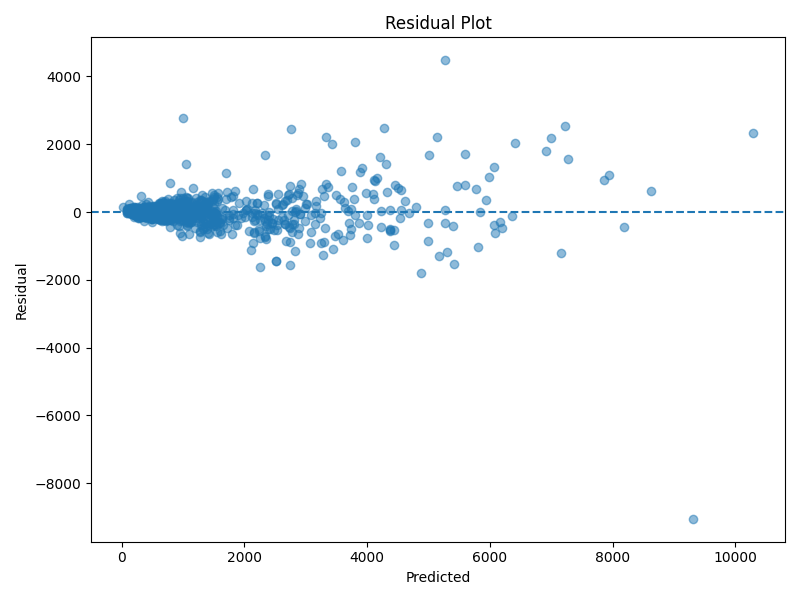

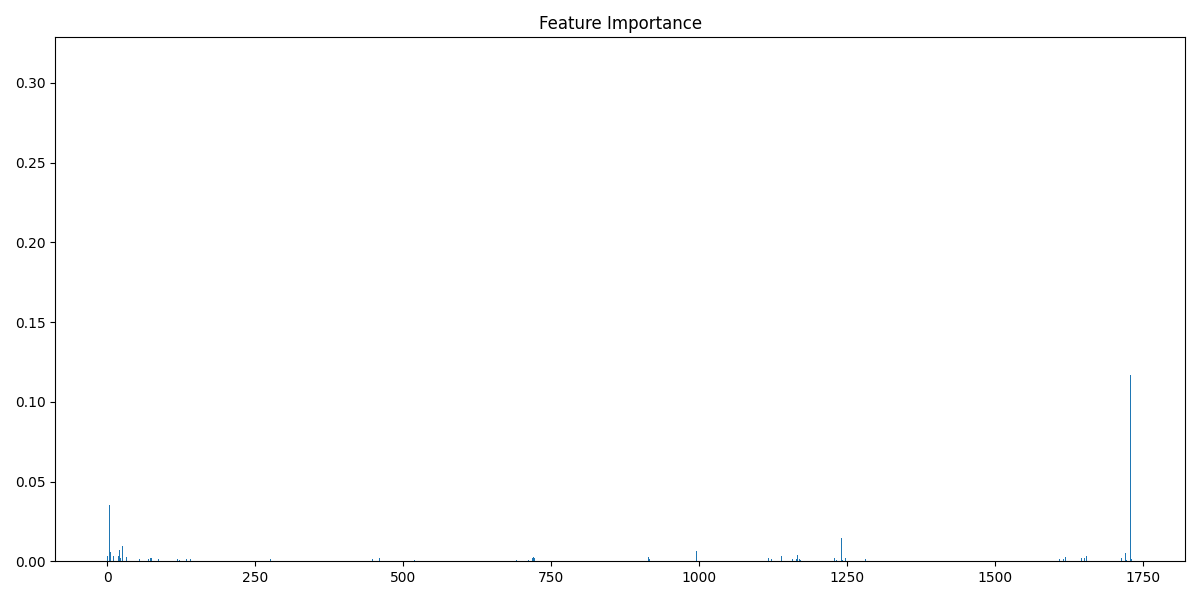

In [9]:
display(Image(filename=str(FIGURES_DIR / "residual_plot.png")))
display(Image(filename=str(FIGURES_DIR / "feature_importance.png")))

## Summary

All four target models (Decision Tree, Random Forest, Gradient Boosting, XGBoost) train and
evaluate successfully on top of the shared preprocessing pipeline, and all comfortably beat the
Linear Regression baseline. In this run, Gradient Boosting and XGBoost are effectively tied for
the top spot (both ~0.89 test R²), with Random Forest close behind — which model comes out
narrowly on top can shift run-to-run at this reduced search budget, since it's a much smaller
hyperparameter sample than the full grid.

The full-scale search (`cv=5`, `n_iter=15` per model, as configured in `tuning.py`) is what
produced the pipeline saved at `models/pipeline.pkl` (XGBoost, test R² = 0.891 — see the
progress report), which `predict.py` loads for inference. The takeaway for this notebook isn't
which single model wins by a fraction of a point, but that the gradient-boosted tree models
(Gradient Boosting, XGBoost) and Random Forest all land in the same strong ~0.88–0.89 R² band,
comfortably ahead of both the Decision Tree and the linear baseline.